<h2 style="color:green" align="center">Predicting if a person would buy life insurnace based on his age using logistic regression</h2>

Above is a binary logistic regression problem as there are only two possible outcomes (i.e. if person buys insurance or he/she doesn't). 

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("data/insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   age               27 non-null     int64
 1   bought_insurance  27 non-null     int64
dtypes: int64(2)
memory usage: 564.0 bytes


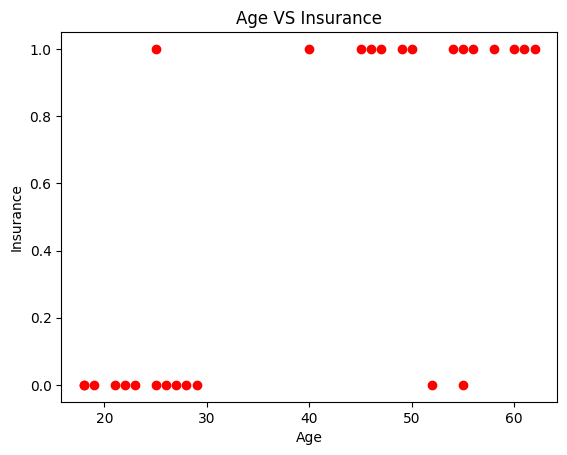

In [4]:
plt.scatter(df.age,df.bought_insurance,color='red',marker='o')
plt.title("Age VS Insurance")
plt.xlabel("Age")
plt.ylabel("Insurance")
plt.show()

In [5]:
df.shape

(27, 2)

In [6]:
df.isnull().sum()

age                 0
bought_insurance    0
dtype: int64

In [7]:
X=df.drop(columns=['bought_insurance'])
y=df['bought_insurance']

In [8]:
X

,age
0,22
1,25
2,47
3,52
4,46
5,56
6,55
7,60
8,62
9,61


In [9]:
y

0     0
1     0
2     1
3     0
4     1
5     1
6     0
7     1
8     1
9     1
10    0
11    0
12    0
13    0
14    1
15    1
16    1
17    1
18    0
19    0
20    0
21    0
22    1
23    1
24    1
25    1
26    0
Name: bought_insurance, dtype: int64

In [10]:
from sklearn.model_selection import train_test_split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [12]:
X_train

,age
0,22
16,25
4,46
24,50
13,29
26,23
15,55
11,28
22,40
17,58


In [13]:
X_test

,age
2,47
19,18
7,60
9,61
25,54
23,45


In [14]:
y_train

0     0
16    1
4     1
24    1
13    0
26    0
15    1
11    0
22    1
17    1
6     0
1     0
10    0
12    0
18    0
20    0
5     1
8     1
21    0
14    1
3     0
Name: bought_insurance, dtype: int64

In [15]:
y_test

2     1
19    0
7     1
9     1
25    1
23    1
Name: bought_insurance, dtype: int64

In [16]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [17]:
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [18]:
y_predicted = model.predict(X_test)
y_predicted

array([1, 0, 1, 1, 1, 1])

In [19]:
pd.DataFrame({'y_test':y_test,'y_predict':y_predicted})

,y_test,y_predict
2,1,1
19,0,0
7,1,1
9,1,1
25,1,1
23,1,1


In [20]:
model.predict_proba(X_test)

array([[0.33806489, 0.66193511],
       [0.93670281, 0.06329719],
       [0.10146698, 0.89853302],
       [0.0913622 , 0.9086378 ],
       [0.18474534, 0.81525466],
       [0.39179807, 0.60820193]])

In [21]:
model.score(X_test,y_test)     #accuracy in classification and R2 in regression

1.0

In [22]:
y_predicted

array([1, 0, 1, 1, 1, 1])

In [23]:
X_test

,age
2,47
19,18
7,60
9,61
25,54
23,45


**model.coef_ indicates value of m in y=m*x + b equation**

In [24]:
model.coef_

array([[0.11608465]])

**model.intercept_ indicates value of b in y=m*x + b equation**

In [25]:
model.intercept_

array([-4.78404869])

**Lets defined sigmoid function now and do the math with hand**

In [26]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [27]:
def prediction_function(age): 
    z = 0.042 * age - 1.53 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z) 
    return y
 


In [29]:
age = 35
prediction_function(age)

0.4850044983805899

**0.485 is less than 0.5 which means person with 35 age will *not* buy insurance**

In [30]:
age = 43
prediction_function(age)

0.568565299077705

**0.485 is more than 0.5 which means person with 43 will buy the insurance**

In [32]:
def predict_probability(age_input):
    """
    Predict probability of class 1 for given age(s)
    age_input : int, float, or list/array of ages
    """
    age_array = np.array(age_input).reshape(-1, 1)  # convert to 2D array
    prob = model.predict_proba(age_array)[:, 1]        # probability of class 1
    return prob

def predict_class(age_input, threshold=0.5):
    """
    Predict class label (0 or 1) for given age(s)
    """
    prob = predict_probability(age_input)
    return (prob > threshold).astype(int)

In [33]:
print(predict_probability(30))  # e.g., [0.42] → 42% chance


[0.21391111]


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [34]:
import math

def prediction(age):
    # Step 1: calculate a score
    z = 0.042 * age - 1.53
    
    # Step 2: turn score into probability
    prob = 1 / (1 + math.exp(-z))
    
    # Step 3: print probability and decision
    print(f"Age: {age}, Probability: {prob:.2f}")
    if prob > 0.5:
        print("Prediction: YES (1)")
    else:
        print("Prediction: NO (0)")


In [35]:
prediction(30)
prediction(45)


Age: 30, Probability: 0.43
Prediction: NO (0)
Age: 45, Probability: 0.59
Prediction: YES (1)
